# Curso: Redes Neurais e Deep Learning

Prof. Denilson Alves Pereira 
https://sites.google.com/ufla.br/denilsonpereira/ 
Departamento de Ciência da Computação - 
Instituto de Ciências Exatas e Tecnológicas - 
Universidade Federal de Lavras

## Rede Neural Simples

Objetivo: apresentar a implementação da arquitetura geral de uma rede neural consistindo de um único neurônio. O código mostra o passo-a-passo para implementação do algoritmo de descida do gradiente.

Versão: Maio, 2021

In [1]:
!pip install numpy matplotlib

import numpy as np # package for scientific computing
import matplotlib.pyplot as plt # library to plot graphs in Python

  Using cached numpy-2.5.2-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.11.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (80 kB)
  Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (118 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.1 kB)
  Using cached pillow-12.3.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (9.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached numpy-2.5.2-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.7 MB)
Using cached matplotlib-3.11.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (10.0 MB)
Using cached contourpy-1.3.

## O Problema

Classificação de um conjunto de dados hipotéticos, conforme descrito a seguir.

Entrada: instâncias compostas por 4 atributos consistindo de zeros e uns.

Saída: a saída de cada instância será um único zero ou um (classificação binária), cujo valor é determinado pelo número no primeiro atributo da entrada.

Observe os dados para treinamento e teste abaixo.

In [2]:
# input training data
train_set_X = np.array([[0, 1, 0, 1, 1, 0],
                        [0, 1, 1, 0, 0, 1],
                        [0, 0, 0, 1, 0, 1],
                        [1, 0, 0, 0, 1, 1]])
# output training data
train_set_Y = np.array([[0, 1, 0, 1, 1, 0]])

In [3]:
# input test data
test_set_X = np.array([[1, 0, 1],
                       [1, 1, 1],
                       [0, 1, 1],
                       [1, 0, 1]])
# output test data
test_set_Y = np.array([[1, 0, 1]])

In [4]:
n = train_set_X.shape[0] # number of attributes
m = train_set_X.shape[1] # number of training examples

print ("Number of attributes: n = " + str(n))
print ("Number of training examples: m = " + str(m))
print ("Train set X shape: " + str(train_set_X.shape))
print ("Train set Y shape: " + str(train_set_Y.shape))
print ("Test set X shape: " + str(test_set_X.shape))
print ("Test set Y shape: " + str(test_set_Y.shape))

Number of attributes: n = 4
Number of training examples: m = 6
Train set X shape: (4, 6)
Train set Y shape: (1, 6)
Test set X shape: (4, 3)
Test set Y shape: (1, 3)


## Arquitetura a ser Implementada

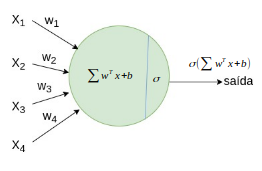

<p>
Será implementado um classificador binário usando a regressão logística (Logistic Regression Classifier) para resolver o problema.
    
**Expressões Matemáticas**:

Para um exemplo $x^{(i)}$:

$$
z^{(i)} = w^T x^{(i)} + b
$$

$$
\hat{y}^{(i)} = a^{(i)} = sigmoid(z^{(i)})
$$

$$
\mathcal{L}(a^{(i)}, y^{(i)}) =
-y^{(i)}\log(a^{(i)})
-(1-y^{(i)})\log(1-a^{(i)})
$$

O custo é computado somando-se todos os exemplos de treino:

$$
J = \frac{1}{m}\sum_{i=1}^{m}\mathcal{L}(a^{(i)}, y^{(i)})
$$

## Inicialização dos Parâmetros

Inicializa os parâmetros $w$ e $b$ com zeros.

O vetor $w$ tem o mesmo número de linhas da entrada X e uma única coluna. O parâmetro $b$ é um escalar.

In [5]:
def initializeParameters(dim):
    """
    Creates a vector of zeros of shape (dim, 1) for w and initializes b to 0.
    Argument:
        dim -- number of parameters for w
    Returns:
        w -- initialized vector w of shape (dim, 1)
        b -- initialized scalar b (bias)
    """
    w = np.zeros((dim, 1))
    b = 0.0
    return w, b

In [6]:
# checking
dim = n
w, b = initializeParameters(dim)
print ("w = " + str(w))
print ("b = " + str(b))

w = [[0.]
 [0.]
 [0.]
 [0.]]
b = 0.0


## Função Sigmóide

Computa $sigmoid(z) = \frac{1}{1 + e^{-(z)}}$

In [7]:
def sigmoid(z):
    """
    Compute the sigmoid activation function of z ==> S(z) = 1/1+e^(-z)
    Arguments:
        z -- A scalar or numpy array of any size.
    Return:
        s -- sigmoid(z)
    """
    s = 1/(1+np.exp(-z))
    return s

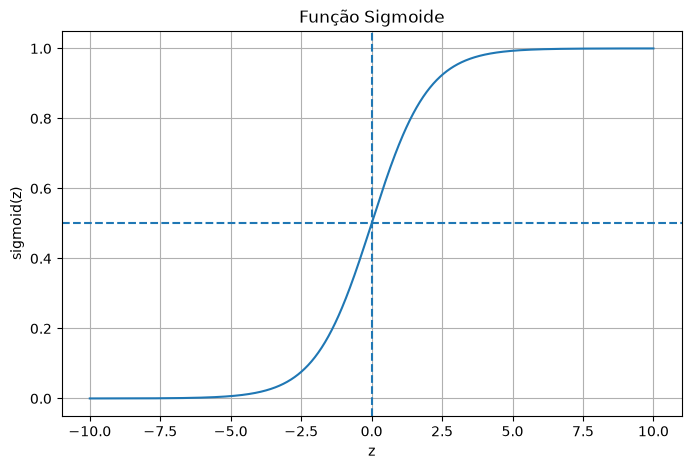

In [9]:
# Valores de entrada
z = np.linspace(-10, 10, 1000)

# Calcula a saída da sigmoide
s = sigmoid(z)

# Plota a função
plt.figure(figsize=(8, 5))
plt.plot(z, s)

plt.title("Função Sigmoide")
plt.xlabel("z")
plt.ylabel("sigmoid(z)")

# Linhas de referência
plt.axhline(0.5, linestyle="--")
plt.axvline(0, linestyle="--")

plt.grid(True)
plt.show()

In [8]:
# checking
print ("sigmoid([0, 1, 2, 8]) = " + str(sigmoid(np.array([0,1,2,8]))))

sigmoid([0, 1, 2, 8]) = [0.5        0.73105858 0.88079708 0.99966465]


## Propagação para Frente (Feed Forward)

Computa $A = \sigma(w^T X + b) = (a^{(1)}, a^{(2)}, ..., a^{(m-1)}, a^{(m)})$

Dica: para entender como é feito o processamento vetorial dos dados, veja um exemplo em https://towardsdatascience.com/inroduction-to-neural-networks-in-python-7e0b422e6c24

In [10]:
def feed_forward(w, b, X):
    """
    Implement the forward propagation step
    Arguments:
        w -- weights, a numpy array of size (n,1)
        b -- bias, a scalar
        X -- data of size (n,m)
    Return:
        A -- sigmoid output for each data example (1,m)
    """
    A = sigmoid(np.dot(w.T,X)+b)  # activation
    return A

In [12]:
# checking
w, b, X = np.array([[0.5],[2.]]), 2., np.array([[1.,-2.,1.],[4.,3.,-2.3]])
A = feed_forward(w, b, X)
print(A)

[[0.99997246 0.99908895 0.10909682]]


In [13]:
# checking
w, b = initializeParameters(dim)
A = feed_forward(w, b, train_set_X)
print(A)

[[0.5 0.5 0.5 0.5 0.5 0.5]]


## Propagação para Trás (Backpropagation)

Computa a Função de Custo: $J = -\frac{1}{m}\sum_{i=1}^{m}y^{(i)}\log(a^{(i)})+(1-y^{(i)})\log(1-a^{(i)})$

Computa as derivadas parciais de $w$ e $b$ dadas pelas fórmulas:

$$ \frac{\partial J}{\partial w} = \frac{1}{m}X(A-Y)^T$$
$$ \frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^m (a^{(i)}-y^{(i)})$$

In [14]:
def backpropagation(A, X, Y):
    """
    Implement the backward propagation step
    Arguments:
        A -- activation function output for each data example (1,m)
        X -- input data, (n,m)
        Y -- true label vector, (1,m)
    Return:
        cost -- cost function output for logistic regression
        grads -- dictionary with:
            dw -- gradient of the loss with respect to w, (n,1) - same shape as w
            db -- gradient of the loss with respect to b, a scalar - same shape as b
    """
    m = X.shape[1]   # number of training examples
    cost = -(np.sum(Y*np.log(A)+(1-Y)*np.log(1-A)))/m   # compute cost
    dw = (np.dot(X,(A-Y).T))/m   # compute dw
    db = (np.sum(A-Y))/m         # compute db
    cost = np.squeeze(cost)      # remove axes of length one from cost
    grads = {"dw": dw,           # pack dw and db in a dictionary
             "db": db}
    return grads, cost

In [15]:
# checking
w, b, X, Y = np.array([[0.5],[2.]]), 2., np.array([[1.,-2.,1.],[4.,3.,-2.3]]), np.array([[1,0,1]])
A = feed_forward(w, b, X)
grads, cost = backpropagation(A, X, Y)
print ("dw = " + str(grads["dw"]))
print ("db = " + str(grads["db"]))
print ("cost = " + str(cost))

dw = [[-0.9630362]
 [ 1.682078 ]]
db = 0.03605274477003254
cost = 3.072152841901268


## Modelo de Treino

Executa o algoritmo de descida do gradiente para otimizar os valores dos parâmetros $w$ e $b$.

o objetivo é aprender $w$ e $b$ que minimiza a função de custo $J$. Para um parâmetro $\theta$, a regra de atualização é $\theta = \theta - \alpha \text{ } d\theta$, onde $\alpha$ é a taxa de aprendizagem.

In [16]:
def train(X, Y, epochs=1000, alpha=0.005, print_cost = False):
    """
    Optimize w and b by running a gradient descent algorithm
    Arguments:
        X -- input data, (n,m)
        Y -- true label vector, (1,m)
        epochs -- number of iterations for optimization
        alpha -- learning rate of the gradient descent update rule
        print_cost -- True to print the loss every 100 steps
    Returns:
        params -- dictionary containing the weights w and bias b
        costs -- list of all the costs computed during the optimization, this will be used to plot the learning curve.
    """
    costs = []                     # cost list for plot
    n = X.shape[0]                 # number of attributes
    w, b = initializeParameters(n) # initialize parameters w and b

    for i in range(epochs):
        # forward and backward propagation steps
        A = feed_forward(w, b, X)
        grads, cost = backpropagation(A, X, Y)
        # retrieve derivatives from grads
        dw = grads["dw"]
        db = grads["db"]
        # update rule
        w = w - alpha * dw
        b = b - alpha * db
        # record the costs
        if i % 100 == 0:
            costs.append(cost)
        # print the cost every 100 training iterations
        if print_cost and i % 100 == 0:
            print ("Cost after iteration %i: %f" %(i, cost))
    params = {"w": w,
              "b": b}
    return params, costs

In [18]:
# checking
X, Y = np.array([[1.,-2.,1.],[4.,3.,-2.3]]), np.array([[1,0,1]])

params, costs = train(X, Y, epochs = 100, alpha = 0.009, print_cost = False)

print ("w = " + str(params["w"]))
print ("b = " + str(params["b"]))

w = [[ 0.47673328]
 [-0.05236593]]
b = 0.14693555740530975


## Predição de Novos Valores

Usa os valores de $w$ e $b$ aprendidos (treinados) para predizer os rótulos de uma nova entrada X. A função é composta de dois passos:

1. Calcula $\hat{Y} = A = \sigma(w^T X + b)$ por meio da função feed_forward

2. Converte as saídas em zero (se ativação <= 0.5) ou 1 (se ativação > 0.5)

In [19]:
def predict(w, b, X):
    '''
    Predict output on new and unseen input data using learned logistic regression parameters (w, b)
    Arguments:
        w -- weights, a numpy array of size (n,1)
        b -- bias, a scalar
        X -- input data, (n,m)
    Returns:
        Y_pred -- a numpy array (1,m) containing all predictions (0/1) for the inputs in X
    '''
    m = X.shape[1]
    Y_pred = np.zeros((1,m))
    w = w.reshape(X.shape[0], 1)
    # compute output A
    A = feed_forward(w, b, X)
    # convert output into 0 (if activation <= 0.5) or 1 (if activation > 0.5)
    for i in range(A.shape[1]):
        if A[0,i] <= 0.5:
            Y_pred[0,i] = 0
        else:
            Y_pred[0,i] = 1
    return Y_pred

In [20]:
# checking
w = np.array([[1.24076588],[0.75978603]])
b = -0.18
X = np.array([[0,0,0],[0,1,1]])
print ("predictions = " + str(predict(w, b, X)))

predictions = [[0. 1. 1.]]


## Avaliação do Modelo

A avaliação é composta pelos seguintes passos:
    
1. Usa os dados de treinamento para gerar o modelo de aprendizagem (aprender $w$ e $b$)

2. Calcula a acurácia obtida pelo modelo de treino

3. Obtém a predição a partir dos dados de teste, com os parâmetros aprendidos

4. Calcula a acurácia obtida nos dados de teste. Esta acurácia é normalmente menor do que aquela obtida pelo modelo de treinamento.

Observe que o custo diminui com o aumento do número de iterações. Como o problema proposto é muito simples de se resolver, altere o número de iterações (epochs) para 1 e veja que ele já obtém uma acurácia de 100\%.

In [18]:
# model evaluation

# training
print("Training...")
params, costs = train(train_set_X, train_set_Y, epochs = 1000, alpha = 0.005, print_cost = True)
w = params["w"] # trained w
b = params["b"] # traind b

# training accuracy
Y_pred = predict(w, b, train_set_X)
print("Train predictions = " + str(Y_pred))
print("Train true values = " + str(train_set_Y))
print("Train accuracy: {} %".format(100 - np.mean(np.abs(Y_pred - train_set_Y)) * 100))

# testing
print("\nTesting...")
Y_pred = predict(w, b, test_set_X)
print("Test predictions = " + str(Y_pred))
print("Test true values = " + str(test_set_Y))
print("Test accuracy: {} %".format(100 - np.mean(np.abs(Y_pred - test_set_Y)) * 100))

Training...
Cost after iteration 0: 0.693147
Cost after iteration 100: 0.656550
Cost after iteration 200: 0.622944
Cost after iteration 300: 0.592033
Cost after iteration 400: 0.563555
Cost after iteration 500: 0.537278
Cost after iteration 600: 0.512996
Cost after iteration 700: 0.490522
Cost after iteration 800: 0.469690
Cost after iteration 900: 0.450349
Train predictions = [[0. 1. 0. 1. 1. 0.]]
Train true values = [[0 1 0 1 1 0]]
Train accuracy: 100.0 %

Testing...
Test predictions = [[1. 0. 1.]]
Test true values = [[1 0 1]]
Test accuracy: 100.0 %


# Fim

Esses foram os passos para criação de uma rede neural simples, composta de um único neurônio.

A seguir, vamos apresentar um exemplo de como essa implementação poderia ser generalizada para uma rede com diversas camadas.

-------------------------------------------

# Generalização da Implementação

O processo descrito anteriormente pode ser generalizado por meio da repetição de multiplicação de matrizes. As redes neurais são organizadas em camadas porque essa estrutura torna simples e eficiente avaliar a rede usando-se operações vetoriais.

Considere a seguinte arquitetura, de uma rede neural com 3 camadas:

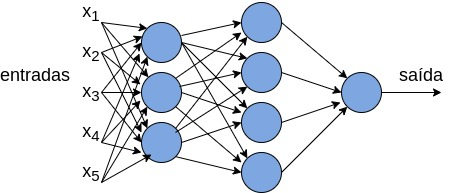

No exemplo acima, a camada de entrada pode ser armazenada em uma matriz [5xm] (cinco linhas e m colunas), onde m é o número de instâncias de entrada.

Os pesos da primeira camada oculta, W1, podem ser armazenados em uma matriz [5x3], cuja matriz transposta é [3x5]. Os biases, b1, das unidades da camada, ficam em uma matriz [3x1]. Assim, cada neurônio tem seus pesos em uma linha de W1.T, de forma que a multiplicação W1.T\*X (np.dot(W1.T,X) avalia a ativação de todos os neurônios daquela camada.

Similarmente, W2 é armazenado em uma matriz [3x4] (ou [4x3] transposta), com as conexões da segunda camada oculta. Os biases b2 têm o formato [4x1].

E W3, os pesos da camada de saída, ficam em uma matriz [4x1] (ou [1x4] transposta), com b3 no formato [1x1].

A propagação para frente (Feed Forward) implementa simplesmente a multiplicação de três matrizes, com a aplicação da função de ativação em cada camada:

z1 =    sigmoid(np.dot(W1.T, X) + b1) # ativação da primeira camada oculta [3x1] <br>
z2 =    sigmoid(np.dot(W2.T, z1) + b2) # ativação da segunda camada oculta [4x1] <br>
saida = sigmoid(np.dot(W3.T, z2) + b3) # ativação da camada de saída [1x1]

A propagação para trás (Backpropagation) usa um raciocínio similar para calcular as derivadas parciais de cada peso, armazenando-as em vetores dW1, dW2, dW3, db1, db2 e db3.